For selected electrodes, run stepwise regression to understand whether progressively refined features improve predictive power.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "5"  # Limit OpenMP
os.environ["MKL_NUM_THREADS"] = "5"  # Limit MKL (Intel Math Kernel Library)
os.environ["OPENBLAS_NUM_THREADS"] = "5"  # Limit OpenBLAS
os.environ["NUMEXPR_MAX_THREADS"] = "5"  # Limit NumExpr if installed

In [3]:
from copy import deepcopy
import itertools
from pathlib import Path
import pickle
import re

import matplotlib.pyplot as plt
import mne
from mne.decoding import ReceptiveField
import numpy as np
import pandas as pd
from sklearn.base import clone, BaseEstimator, TransformerMixin, check_is_fitted
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_squared_error
import seaborn as sns
from tqdm.auto import tqdm
tqdm.pandas()
from scipy import stats
import torch

from src.data import add_metadata_features
from src.stimuli import POD_dict
from src.models.trf import estimate_trf, TRF
from src.viz import plot_epochs

In [29]:
all_epochs_path = list(Path("outputs/epochs_preprocessed").rglob("*_epo.fif"))
all_results_path = list(Path("outputs/causal4/find_As").rglob("*_results.csv"))
all_decoders_path = list(Path("outputs/causal4/find_As").rglob("*_decoders.pt"))
electrodes_paths = list(Path("outputs/causal4/find_speech_responsive").glob("*_results.csv"))

outdir = "."

global_features = [("onset", "onset")]

feature_progressions = {
    "acoustic": [
        ("categorical_acoustic_cue", "onset"),
        ("linear_acoustic_cue", "onset"),
    ],

    # "mismatch": [
    #     # ("mismatch", "PoD"),
    #     ("mismatch_left_right", "PoD"),
    #     ("belief_update", "PoD"),
    # ],
}

num_folds = 2
Cs = np.logspace(-4, 2, 7)

In [30]:
electrode_df = pd.concat([pd.read_csv(path) for path in electrodes_paths]).set_index(["subject", "electrode_idx"])

In [5]:
A_results = pd.concat([pd.read_csv(p) for p in all_results_path], ignore_index=True)

In [6]:
A_decoders = {
    re.findall(r"/([^/]+)_decoders\.pt", str(p))[0]:
    torch.load(p) for p in tqdm(all_decoders_path)}

  0%|          | 0/10 [00:00<?, ?it/s]

/scratch/jgauthier/transformers/lib/python3.10/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/scratch/jgauthier/transformers/lib/python3.10/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/scratch/jgauthier/transformers/lib/python3.10/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.6.1 w

In [32]:
A_summary = A_results.query("A").groupby(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]).roc_auc.mean().reset_index()
A_summary

,subject,electrode_idx,phoneme_pair,smin,smax,roc_auc
0,EC243,85,dn,40,70,0.686000
1,EC243,86,dn,40,70,0.694000
2,EC243,87,bm,40,70,0.846000
3,EC243,87,dn,40,70,0.744000
4,EC243,96,dn,40,70,0.680000
...,...,...,...,...,...,...
162,EC287,114,dn,40,70,0.757143
163,EC287,139,bm,40,70,0.790476
164,EC287,185,dn,40,70,0.838095
165,EC287,190,dn,40,70,0.838095


In [34]:
# merge in ROI information
A_summary = pd.merge(A_summary, electrode_df.reset_index(), on=["subject", "electrode_idx"], how="left", validate="m:1")

In [35]:
assert A_summary.smin.nunique() == 1
assert A_summary.smax.nunique() == 1

In [36]:
mne.set_config("MNE_TQDM", "off")

In [37]:
epochs = {re.findall(r"/([^/]+)_epo\.fif", str(epochs_path))[0]:
          mne.read_epochs(epochs_path, verbose=False)
            for epochs_path in tqdm(all_epochs_path)}
for ep in epochs.values():
    ep.metadata = add_metadata_features(ep.metadata)
    ep.metadata["onset"] = 1.0

  0%|          | 0/10 [00:00<?, ?it/s]

Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 101 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns
Replacing existing metadata with 100 columns


In [38]:
# Add stimulus correlation information to A_summary
for idx, row in tqdm(A_summary.iterrows()):
    outcomes = pd.concat([
        A_decoders[row.subject]["outcomes"][row.subject, row.electrode_idx, row.phoneme_pair, row.smin, row.smax],
        A_decoders[row.subject]["held_out_outcomes"][row.subject, row.electrode_idx, row.phoneme_pair, row.smin, row.smax]
    ]).groupby("epoch_idx").decoder_proba.mean().reset_index()
    outcomes = pd.merge(outcomes, epochs[row.subject].metadata, how="left",
                        left_on="epoch_idx", right_index=True, validate="1:1")
    spearmanr, pval = stats.spearmanr(outcomes["decoder_proba"], outcomes["resampled"])
    A_summary.loc[idx, "stimulus_correlation"] = spearmanr

0it [00:00, ?it/s]

In [39]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, peak_widths

def get_peak_region(subject, electrode_idx, phoneme_pair, smin, smax):
    coefs = np.concatenate([pipeline.steps[-1][1].coef_
                            for pipeline in A_decoders[subject]["models"][subject, electrode_idx, phoneme_pair, smin, smax]], axis=0)
    smoothed_coefs = gaussian_filter1d(coefs.mean(axis=0), sigma=2)
    mag = np.abs(smoothed_coefs)

    # heuristic thresholds: tweak as needed
    prom_thresh = 0.5 * np.std(mag)       # how "tall" relative to baseline noise
    min_distance = max(3, len(mag)//50)   # keep peaks separated

    peaks, props = find_peaks(mag, prominence=prom_thresh, distance=min_distance)

    # fallback if nothing clears the bar
    if peaks.size == 0:
        # drop the threshold and try again
        peaks, props = find_peaks(mag, prominence=0.2 * np.std(mag))
        if peaks.size == 0:
            # still nothing — pick the global max as a last resort
            pk = int(np.argmax(mag))
            chosen_pk = pk
        else:
            chosen_pk = peaks[np.argmax(props["prominences"])]
    else:
        chosen_pk = peaks[np.argmax(props["prominences"])]

    # --- estimate peak width (at half-prominence height by default) ---
    w_results = peak_widths(mag, [chosen_pk], rel_height=0.5)
    left_f, right_f = w_results[2][0], w_results[3][0]  # fractional sample indices

    # clamp to valid integer indices
    start_i = int(np.floor(max(0, left_f)))
    end_i   = int(np.ceil(min(len(mag) - 1, right_f)))

    # ---- OPTIONAL: convert back to global sample/time if your decoder window is [smin, smax) ----
    # In your example, smin=40, smax=70
    smin, smax = 40, 70
    global_start = smin + start_i
    global_end   = smin + end_i

    # OPTIONAL: times for plotting/labels
    times_window = ep.times[smin:smax]
    start_t = times_window[start_i]
    end_t   = times_window[min(end_i, len(times_window)-1)]

    # print(f"peak @ idx {chosen_pk} (window), range [{start_i}, {end_i}] "
    #     f"== [{start_t:.3f}s, {end_t:.3f}s]; global samples [{global_start}, {global_end}]")

    # plt.plot(smoothed_coefs)
    # plt.axvline(start_i, color="red", ls="--")
    # plt.axvline(end_i, color="red", ls="--")
    return pd.Series({"peak_start": global_start, "peak_end": global_end})

A_summary = pd.concat([A_summary, A_summary.apply(lambda row: get_peak_region(row.subject, row.electrode_idx, row.phoneme_pair, row.smin, row.smax), axis=1)], axis=1)

/tmp/ipykernel_1573730/2625954486.py:30: PeakPropertyWarning: some peaks have a prominence of 0
  w_results = peak_widths(mag, [chosen_pk], rel_height=0.5)
/tmp/ipykernel_1573730/2625954486.py:30: PeakPropertyWarning: some peaks have a width of 0
  w_results = peak_widths(mag, [chosen_pk], rel_height=0.5)


In [40]:
trf_tmin, trf_tmax = next(iter(epochs.values())).times[[A_summary.smin.iloc[0], A_summary.smax.iloc[0]]]

In [41]:
all_epochs_df = pd.concat({subject: ep.metadata for subject, ep in epochs.items()}, names=["subject", "epoch_idx"]).reset_index()
all_epochs_df = pd.merge(all_epochs_df, A_summary.rename(columns={"electrode_idx": "channel"}), on=["subject", "phoneme_pair"])
all_epochs_df = all_epochs_df[~all_epochs_df.channel.isna()]
all_epochs_df["channel"] = all_epochs_df["channel"].astype(int)
all_epochs_df["facet_label"] = all_epochs_df.subject + " " + (all_epochs_df.channel + 1).astype(str)
all_epochs_df["resampled_str"] = all_epochs_df.resampled.astype(int).astype(str)
all_epochs_df = all_epochs_df.set_index(["subject", "channel", "epoch_idx"])

In [42]:
epoch_data = {subject: epochs[subject].get_data() for subject in epochs}

In [43]:
plot_sample = all_epochs_df.groupby(["subject", "channel"]).groups.keys()
plot_sample_idxs = np.random.choice(len(plot_sample), size=min(20, len(plot_sample)), replace=False)
plot_sample = [plot_sample_i for idx, plot_sample_i in enumerate(plot_sample) if idx in plot_sample_idxs]
plot_epochs_df = pd.merge(pd.DataFrame(plot_sample, columns=["subject", "channel"]),
                          all_epochs_df.reset_index(), on=["subject", "channel"],
                          how="left").set_index(["subject", "channel", "epoch_idx"])

plot_sample_data = {(subject, i): epoch_data[subject][:, i, :]
                       for (subject, i), _ in all_epochs_df.groupby(["subject", "channel"])
                       if (subject, i) in plot_sample}

/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend()

  0%|          | 0/60 [00:00<?, ?it/s]

/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


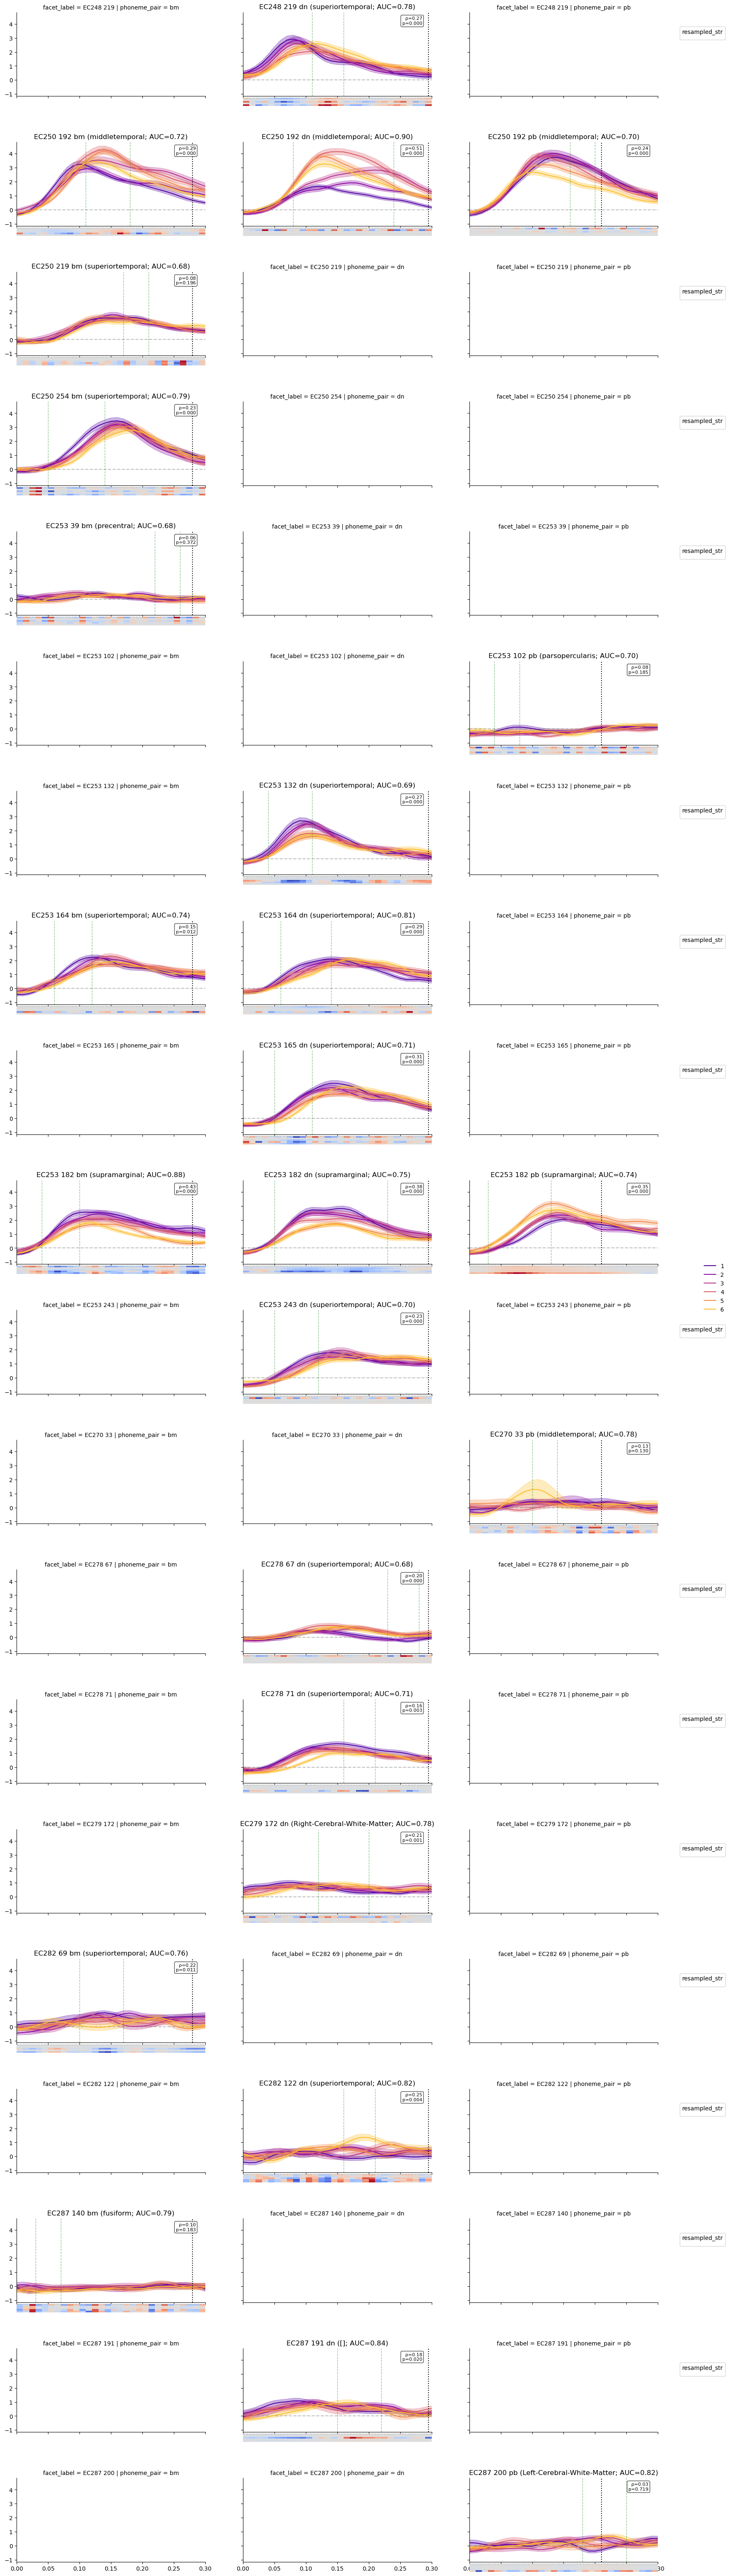

In [47]:
g, _, _ = plot_epochs(plot_sample_data,
                      plot_epochs_df, hue="resampled_str", hue_order=["1", "2", "3", "4", "5", "6"], palette="plasma",
                      epoch_times=ep.times, smoke_test=False,
                      aspect=1.5)
for ax in g.axes.flat:
    ax.set_xlim(trf_tmin, trf_tmax)

def add_coef_heatmap(data, pbar=None, **kwargs):
    subject = data.subject.iloc[0]
    electrode_idx = data.channel.iloc[0]
    phoneme_pair = data.phoneme_pair.iloc[0]
    roi = data.roi.iloc[0]

    A_result_row = A_summary.query("subject == @subject and electrode_idx == @electrode_idx and phoneme_pair == @phoneme_pair")
    assert len(A_result_row) == 1
    smin = A_result_row.smin.iloc[0]
    smax = A_result_row.smax.iloc[0]

    ## Annotate with A performance
    ax = plt.gca()
    ax.set_title(f"{subject} {electrode_idx + 1} {phoneme_pair} ({roi}; AUC={A_result_row.roc_auc.iloc[0]:.2f})")

    # Add peak measurement region
    peak_start = A_result_row.peak_start.iloc[0]
    peak_end = A_result_row.peak_end.iloc[0]
    ax.axvline(ep.times[peak_start], color="forestgreen", ls="--", lw=1, alpha=0.5)
    ax.axvline(ep.times[peak_end], color="forestgreen", ls="--", lw=1, alpha=0.5)

    ## Compute stimulus correlation
    outcomes = pd.concat([
        A_decoders[subject]["outcomes"][subject, electrode_idx, phoneme_pair, smin, smax],
        A_decoders[subject]["held_out_outcomes"][subject, electrode_idx, phoneme_pair, smin, smax]
    ]).groupby("epoch_idx").decoder_proba.mean().reset_index()
    outcomes = pd.merge(outcomes, epochs[subject].metadata, how="left",
                        left_on="epoch_idx", right_index=True, validate="1:1")
    spearmanr, pval = stats.spearmanr(outcomes["decoder_proba"], outcomes["resampled"])
    ax.text(0.95, 0.95, f"ρ={spearmanr:.2f}\np={pval:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ## Plot decoder coefficients

    decoders = A_decoders[subject]["models"][subject, electrode_idx, phoneme_pair, smin, smax]
    decoder_coefs = np.concatenate([pipeline.steps[-1][1].coef_ for pipeline in decoders], axis=0)

    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    inset_ax = inset_axes(ax, width="100%", height="10%", loc="lower center",
                        bbox_to_anchor=(0, -0.12, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
    inset_ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.5)
    # times = ep.times[smin:smax]
    # sns.lineplot(x=times, y=decoder_coefs.mean(axis=0), ax=inset_ax)

    sns.heatmap(decoder_coefs, ax=inset_ax, cbar=False, xticklabels=False, yticklabels=False,
                cmap="coolwarm", center=0)
    inset_ax.tick_params(left=False, bottom=False)

    pbar.update(1)

with tqdm(total=len(g.axes.flat)) as pbar:
    g.map_dataframe(add_coef_heatmap, pbar=pbar)

g.add_legend()

/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


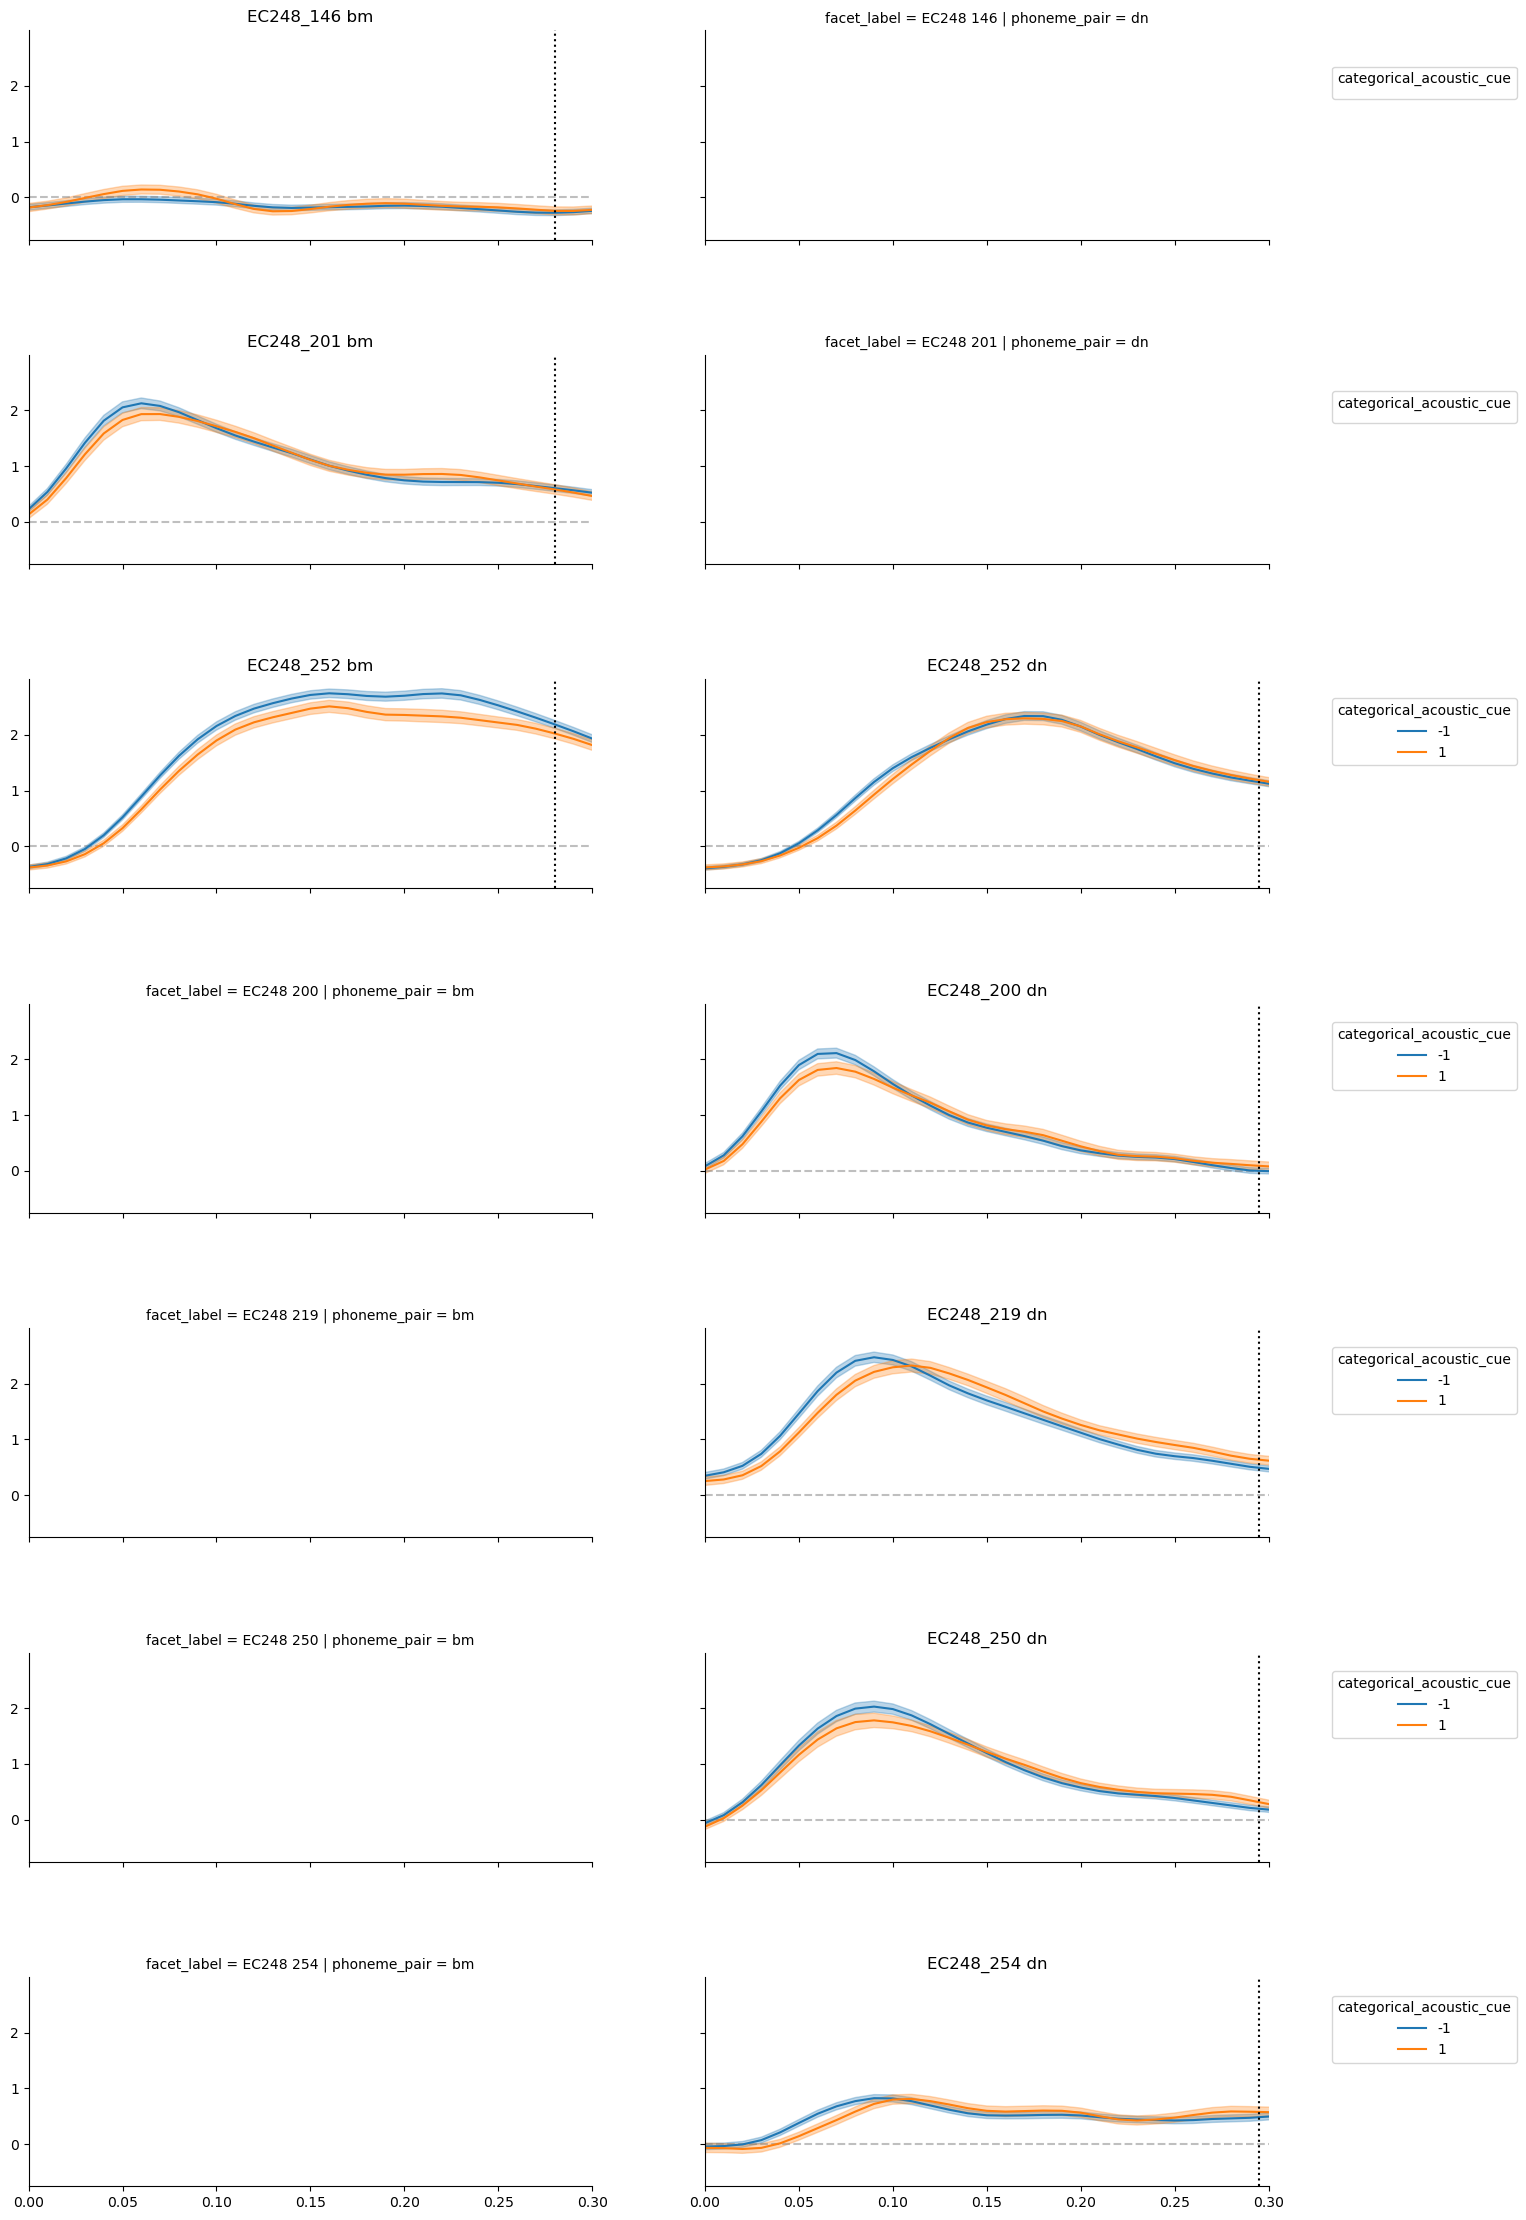

In [ ]:
# g, _, _ = plot_epochs({(subject, i): ep.get_data()[:, i, :]
#              for subject, i in A_summary[["subject", "electrode_idx"]].itertuples(index=False)},
#             epoch_df, hue="categorical_acoustic_cue", epoch_times=ep.times)
# for ax in g.axes.flat:
#     ax.set_xlim(trf_tmin, trf_tmax)

In [48]:
def get_peak_value(row):
    subject, electrode_idx, epoch_idx = row.name
    phoneme_pair = row.phoneme_pair
    smin = row.smin
    smax = row.smax

    ret = epoch_data[subject][epoch_idx, electrode_idx, row.peak_start:row.peak_end].mean()
    return ret

all_epochs_df["peak_value"] = all_epochs_df.progress_apply(get_peak_value, axis=1)

  0%|          | 0/47424 [00:00<?, ?it/s]

/tmp/ipykernel_1573730/1789933309.py:7: RuntimeWarning: Mean of empty slice.
  ret = epoch_data[subject][epoch_idx, electrode_idx, row.peak_start:row.peak_end].mean()
/scratch/jgauthier/transformers/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [49]:
all_epochs_df["facet_label_spec"] = all_epochs_df.facet_label + " " + all_epochs_df.phoneme_pair
A_summary["facet_label_spec"] = A_summary.subject + " " + (A_summary.electrode_idx + 1).astype(str) + " " + A_summary.phoneme_pair

/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/scratch/jgauthier/

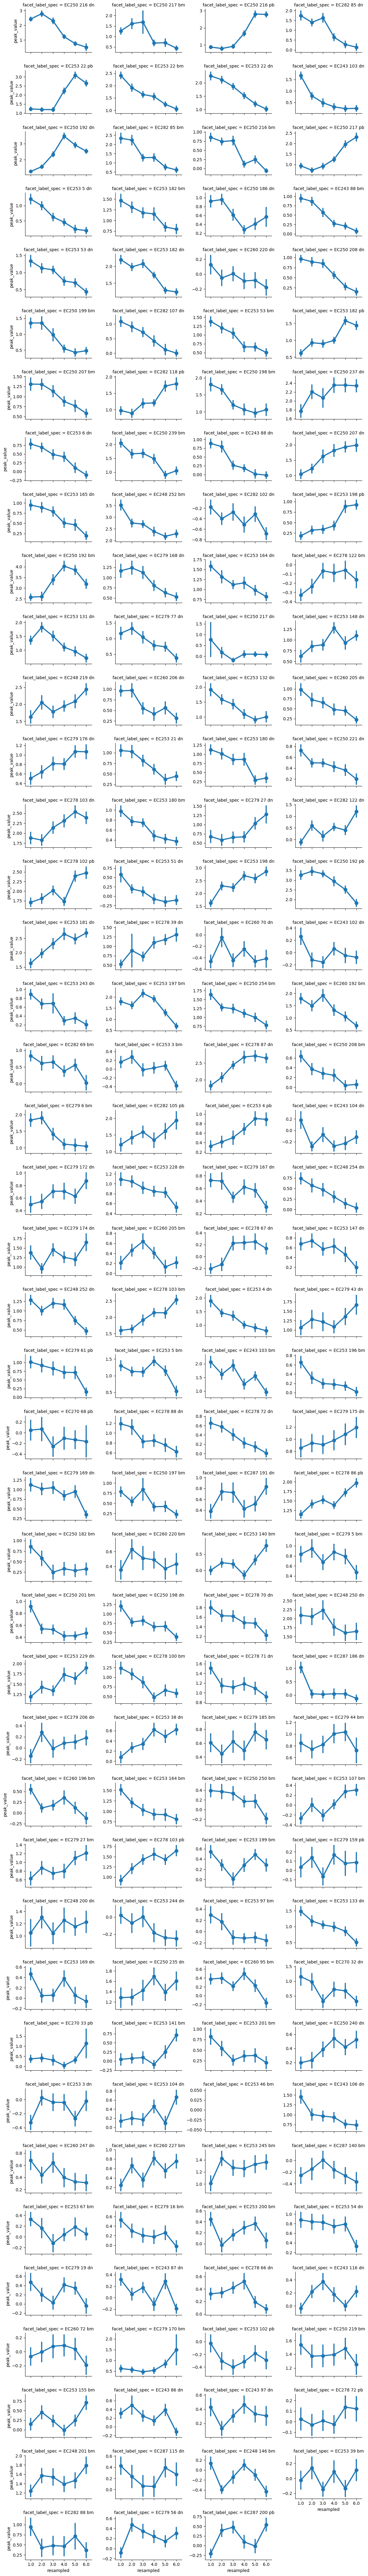

In [50]:
sns.catplot(data=all_epochs_df, x="resampled", y="peak_value",
            col="facet_label_spec", col_wrap=4,
            col_order=A_summary.sort_values("stimulus_correlation", ascending=False).facet_label_spec,
            kind="point", height=2, aspect=1.5, errorbar="se", sharey=False)

In [51]:
def get_resampled_mean_vec(rows):
    ret = rows.groupby("resampled").peak_value.mean().reindex([1, 2, 3, 4, 5, 6]).values
    if not np.isnan(ret).any():
        return ret
resampled_vec_dict = all_epochs_df.groupby(["subject", "channel", "phoneme_pair"]).apply(get_resampled_mean_vec).dropna().to_dict()

/tmp/ipykernel_1573730/1905498405.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resampled_vec_dict = all_epochs_df.groupby(["subject", "channel", "phoneme_pair"]).apply(get_resampled_mean_vec).dropna().to_dict()


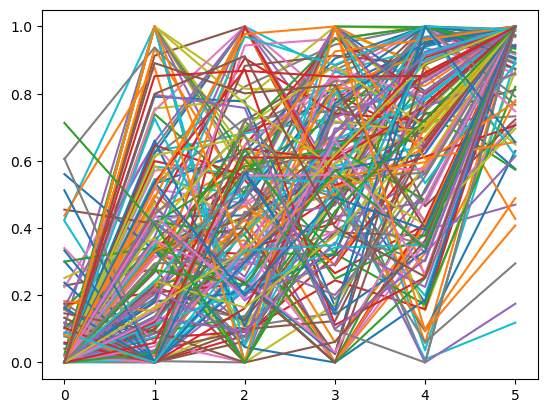

In [52]:
resampled_vecs = np.stack(list(resampled_vec_dict.values()))
resampled_vecs -= resampled_vecs.min(axis=1, keepdims=True)
resampled_vecs /= resampled_vecs.max(axis=1, keepdims=True)
slopes = np.sign(resampled_vecs[:, -1] - resampled_vecs[:, 0])

flip_mask = slopes < 0
resampled_vecs[flip_mask] *= -1  # flip those with negative slope
resampled_vecs[flip_mask] += 1   # make all range on [0, 1]
for l in resampled_vecs:
    plt.plot(l)

In [53]:
resampled_items = pd.DataFrame(resampled_vec_dict.keys(), columns=["subject", "channel", "phoneme_pair"])

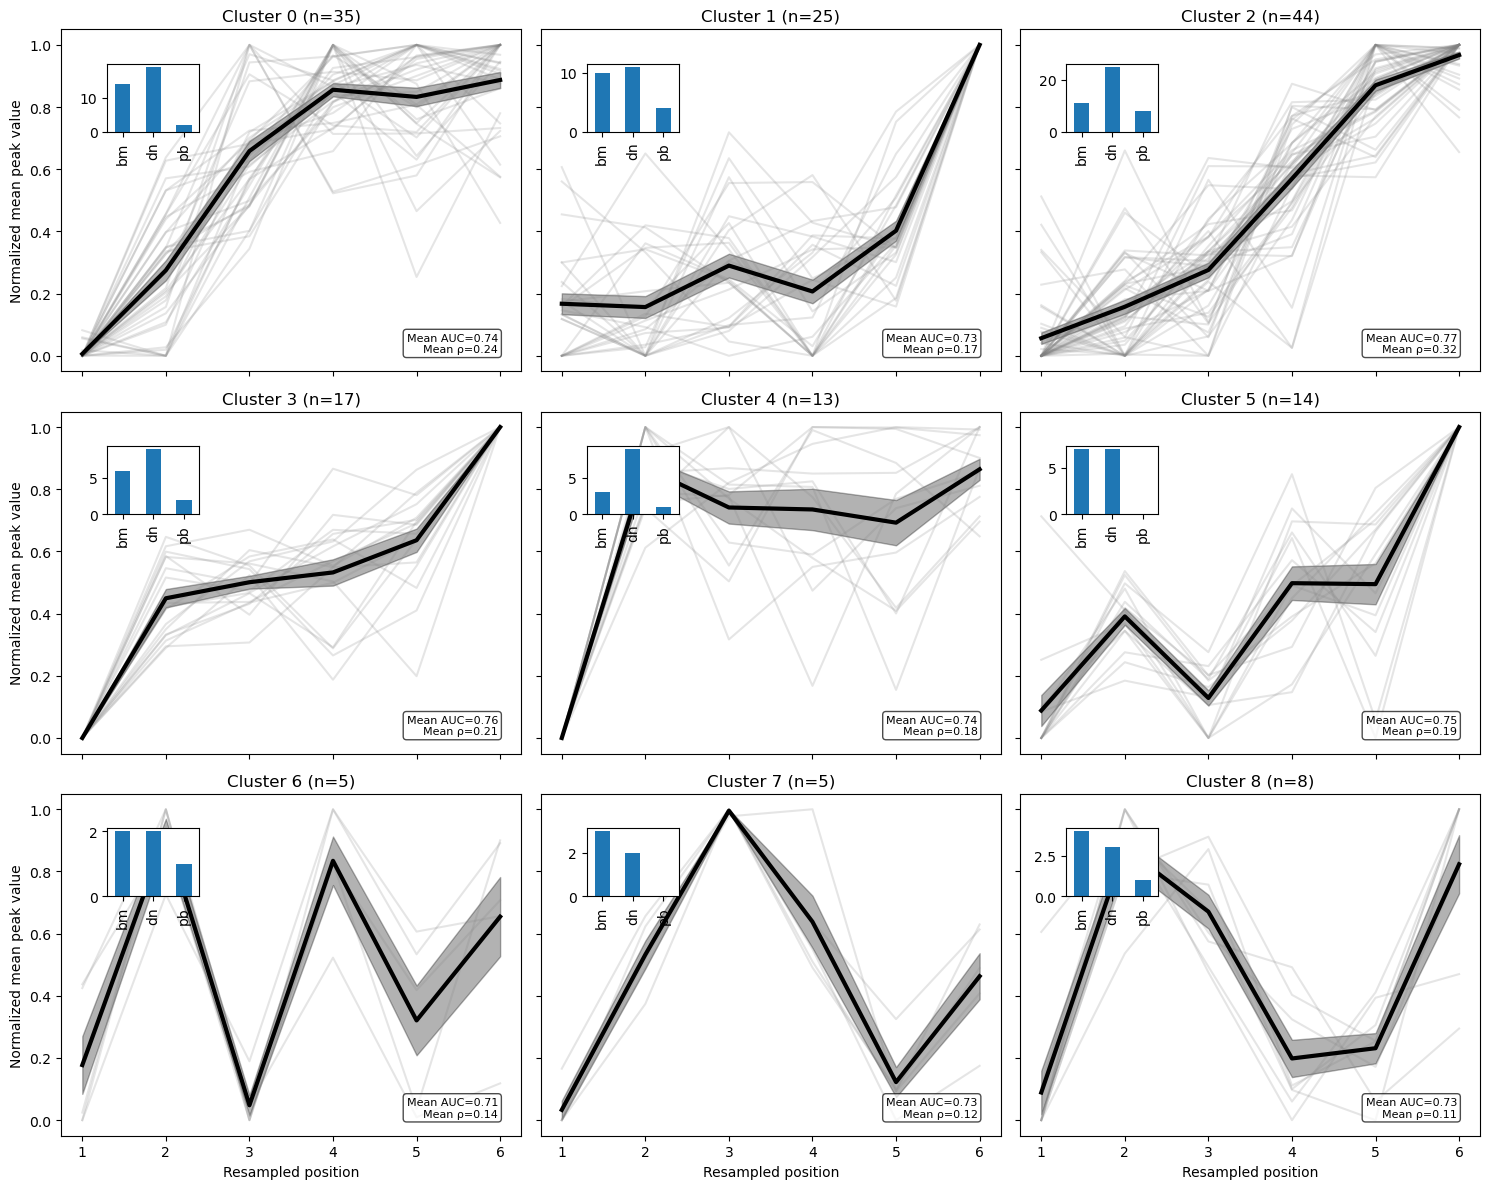

In [55]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = resampled_vecs
pca = PCA(n_components=0.9)
X = pca.fit_transform(X)
# clust = KMeans(n_clusters=12, random_state=0, n_init="auto").fit(X)
clust = AgglomerativeClustering(n_clusters=None, distance_threshold=1.6).fit(X)
n_clusters = clust.n_clusters_
labels = clust.labels_
resampled_items["cluster_label"] = labels

n_cols = 3
n_rows = int(np.ceil(n_clusters / n_cols))
f, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4), sharex=True, sharey=True)

for ax, i in zip(axs.flat, range(n_clusters)):
    resampled_items_i = resampled_items[labels == i]
    ax.set_title(f"Cluster {i} (n={len(resampled_items_i)})")
    resampled_steps = np.arange(1, 7)

    if i // n_cols == n_rows - 1:
        ax.set_xlabel("Resampled position")

    if i % n_cols == 0:
        ax.set_ylabel("Normalized mean peak value")

    for l in resampled_vecs[labels == i]:
        ax.plot(resampled_steps, l, alpha=0.2, color="gray")

    # plot centroid
    centroid_xs = resampled_vecs[labels == i]
    centroid_mean = centroid_xs.mean(axis=0)
    ax.plot(resampled_steps, centroid_mean, color="black", lw=3)
    centroid_std = centroid_xs.std(axis=0)
    centroid_sem = centroid_xs.std(axis=0) / np.sqrt(len(centroid_xs))
    ax.fill_between(resampled_steps,
                     centroid_mean - centroid_sem,
                     centroid_mean + centroid_sem,
                     color="black", alpha=0.3)
    
    # add inset axis showing phoneme pair distribution as a stacked bar plot
    phoneme_pair_distribution = resampled_items_i.phoneme_pair.value_counts().reindex(sorted(all_epochs_df.phoneme_pair.unique())).fillna(0).astype(int)
    inset_ax = ax.inset_axes([0.1, 0.7, 0.2, 0.2])
    phoneme_pair_distribution.plot(kind="bar", ax=inset_ax)
    inset_ax.set_xlabel(None)
    # inset_ax = ax.inset_axes([0.05, 0.55, 0.1, 0.4])
    # offset = 0
    # for phoneme_pair in phoneme_pair_distribution.index:
    #     count = phoneme_pair_distribution[phoneme_pair]
    #     inset_ax.bar([1], [count], bottom=offset)
    #     offset += count
    # inset_ax.set_xlabel(None)
    # inset_ax.set_ylabel(None)
    # inset_ax.spines["top"].set_visible(False)
    # inset_ax.spines["right"].set_visible(False)
    # inset_ax.spines["left"].set_visible(False)
    # inset_ax.spines["bottom"].set_visible(False)
    # inset_ax.set_xticks([])
    # inset_ax.set_yticks([])

    # compute average ROC-AUC and stimulus correlation for this cluster
    A_rows = pd.merge(resampled_items_i, A_summary, left_on=["subject", "channel", "phoneme_pair"],
                        right_on=["subject", "electrode_idx", "phoneme_pair"], validate="1:1")
    # add as text
    ax.text(0.95, 0.05,
            f"Mean AUC={A_rows.roc_auc.mean():.2f}\n"
            f"Mean ρ={A_rows.stimulus_correlation.mean():.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

f.tight_layout()

In [57]:
A_summary = pd.merge(A_summary, resampled_items, left_on=["subject", "electrode_idx", "phoneme_pair"],
                     right_on=["subject", "channel", "phoneme_pair"], how="left", validate="1:1")

/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


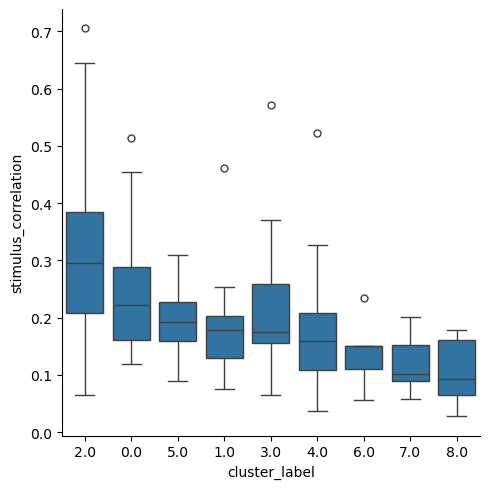

In [63]:
sns.catplot(data=A_summary, x="cluster_label", y="stimulus_correlation", kind="box", order=A_summary.groupby("cluster_label").stimulus_correlation.median().sort_values(ascending=False).index)

/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


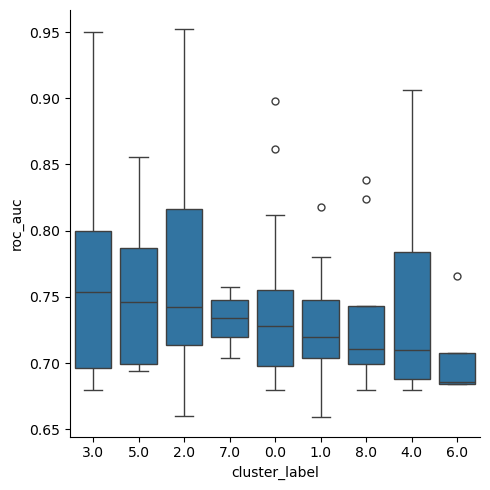

In [62]:
sns.catplot(data=A_summary, x="cluster_label", y="roc_auc", kind="box", order=A_summary.groupby("cluster_label").roc_auc.median().sort_values(ascending=False).index)

<Axes: xlabel='cluster_label', ylabel='phoneme_pair'>

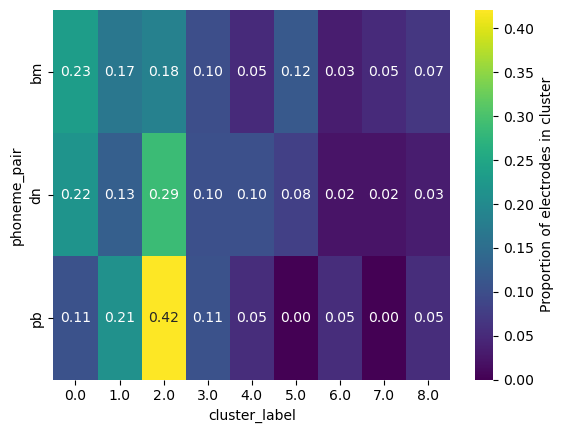

In [73]:
cluster_by_ph = A_summary.groupby("phoneme_pair").cluster_label.value_counts().unstack("cluster_label").fillna(0).astype(int)
cluster_by_ph_proportion = cluster_by_ph.div(cluster_by_ph.sum(axis=1), axis=0)
sns.heatmap(cluster_by_ph_proportion, cmap="viridis", cbar_kws={"label": "Proportion of electrodes in cluster"}, annot=True, fmt=".2f")

In [75]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(cluster_by_ph)
print(f"Chi2={chi2:.2f}, p={p:.3f}, dof={dof}")

Chi2=12.09, p=0.738, dof=16


In [76]:
manual_elec_labelings = {
    "stack": [
        ("EC243", 102, "bm"),
        ("EC260", 219, "bm"),
        ("EC243", 103, "bm"),
        ("EC243", 103, "pb"),
        ("EC260", 222, "pb"),
        ("EC243", 105, "bm"),
        ("EC260", 220, "pb"),
        ("EC279", 6, "dn"),
        ("EC248", 365, "dn"),
        ("EC253", 196, "dn"),
        ("EC253", 2, "dn"),
        ("EC279", 167, "dn"),
        ("EC287", 59, "dn"),
        ("EC279", 4, "bm"),
        ("EC279", 4, "dn"),
        ("EC278", 27, "bm"),
        ("EC260", 206, "bm"),
        ("EC260", 206, "pb"),
        ("EC278", 90, "dn"),
    ],

    "alligator": [
        ("EC243", 102, "dn"),
        ("EC243", 102, "pb"),
        ("EC260", 204, "dn"),
        ("EC260", 91, "dn"),
        ("EC260", 93, "dn"),
        ("EC243", 197, "bm"),
        ("EC260", 109, "dn"),
        ("EC243", 103, "dn"),
        ("EC278", 121, "bm"),
        ("EC260", 92, "dn"),
        ("EC250", 216, "pb"),
        ("EC243", 213, "dn"),
        ("EC248", 364, "dn"),
        ("EC250", 207, "dn"),
        ("EC248", 253, "dn"),
        ("EC282", 97, "dn"),
        ("EC278", 27, "dn"),
        ("EC282", 115, "pb"),
        ("EC278", 90, "pb"),
        ("EC279", 76, "bm"),
    ],

    "loo": [
        ('EC260', 204, 'dn'),
        ('EC260', 204, 'pb'),
        ('EC260', 91, 'bm'),
        ('EC260', 93, 'pb'),
        ('EC243', 197, 'dn'),
        ('EC260', 219, 'bm'),
        ('EC260', 219, 'dn'),
        ('EC278', 121, 'dn'),
        ('EC243', 119, 'bm'),
        ('EC243', 119, 'dn'),
        ('EC260', 222, 'bm'),
        ('EC260', 222, 'dn'),
        ('EC243', 105, 'pb'),
        ('EC260', 92, 'bm'),
        ('EC250', 216, 'bm'),
        ('EC260', 221, 'dn'),
        ('EC260', 221, 'pb'),
        ('EC248', 381, 'dn'),
        ('EC260', 220, 'dn'),
        ('EC253', 212, 'dn'),
        ('EC250', 215, 'bm'),
        ('EC250', 215, 'dn'),
        ('EC248', 364, 'bm'),
        ('EC260', 76, 'bm'),
        ('EC260', 76, 'dn'),
        ('EC270', 122, 'dn'),
        ('EC282', 116, 'bm'),
        ('EC287', 124, 'pb'),
        ('EC253', 196, 'pb'),
        ('EC248', 253, 'dn'),
        ('EC279', 167, 'pb'),
        ('EC279', 152, 'dn'),
        ('EC279', 152, 'pb'),
        ('EC287', 5, 'pb'),
        ('EC270', 140, 'dn'),
        ('EC260', 206, 'dn'),
        ('EC278', 90, 'bm'),
        ('EC243', 228, 'dn'),
        ('EC243', 72, 'bm'),
        ('EC243', 72, 'dn'),
        ('EC279', 11, 'pb'),
        ('EC279', 76, 'dn'),
    ]
}

In [77]:
manual_label_df = pd.concat({label: pd.DataFrame(label_df, columns=["subject", "electrode_idx", "phoneme_pair"])
           for label, label_df in manual_elec_labelings.items()}, names=["manual_label"]).droplevel(-1).reset_index()

<Axes: xlabel='manual_label', ylabel='cluster_label'>

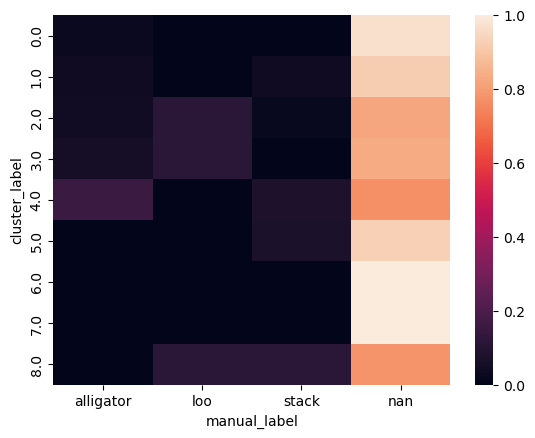

In [87]:
A_and_manual = pd.merge(A_summary, manual_label_df, on=["subject", "electrode_idx", "phoneme_pair"], how="left")
sns.heatmap(A_and_manual.groupby("cluster_label").manual_label.value_counts(dropna=False, normalize=True).unstack("manual_label").fillna(0))

In [112]:
B_results = pd.read_csv("outputs/causal4/annotated_B_results.csv")
B_results = B_results[B_results["Temporal pattern"] != "drop"]

In [113]:
pd.merge(A_summary, B_results, on=["subject", "electrode_idx", "phoneme_pair"], how="left").groupby(["subject", "electrode_idx", "phoneme_pair", "cluster_label"]).apply(lambda xs: ~xs.p_val_min.isna().all()) \
    .groupby("cluster_label").agg(["sum", "count", "mean"])

/tmp/ipykernel_1573730/579041587.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pd.merge(A_summary, B_results, on=["subject", "electrode_idx", "phoneme_pair"], how="left").groupby(["subject", "electrode_idx", "phoneme_pair", "cluster_label"]).apply(lambda xs: ~xs.p_val_min.isna().all()) \


,sum,count,mean
cluster_label,,,
0.0,3,35,0.085714
1.0,1,25,0.040000
2.0,5,44,0.113636
3.0,0,17,0.000000
4.0,1,13,0.076923
5.0,1,14,0.071429
6.0,1,5,0.200000
7.0,1,5,0.200000
8.0,2,8,0.250000


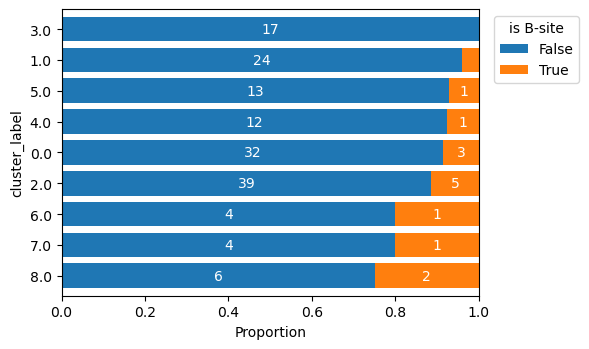

In [127]:

# 1) Merge and collapse to ONE boolean per (subject, electrode, pair, cluster)
merged = pd.merge(
    A_summary, B_results,
    on=["subject", "electrode_idx", "phoneme_pair"],
    how="left"
)

# True if any row in that group has a non-NaN p_val_min
has_sig = (
    merged
    .groupby(["subject", "electrode_idx", "phoneme_pair", "cluster_label"])["p_val_min"]
    .apply(lambda s: ~s.isna().all())
    .rename("has_sig")
    .reset_index()
)

# 2) Count True/False per cluster
counts = (
    has_sig
    .groupby(["cluster_label", "has_sig"])
    .size()
    .unstack("has_sig", fill_value=0)
    .reindex(columns=[False, True], fill_value=0)  # ensure consistent column order
)

# 3) Convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# (optional) sort clusters by True proportion descending
order = props[True].sort_values(ascending=False).index
props = props.loc[order]

# 4) Plot
fig, ax = plt.subplots(figsize=(6, 0.4 * len(props)))
props.plot(kind="barh", stacked=True, ax=ax, width=0.8)

ax.set_xlabel("Proportion")
ax.set_ylabel("cluster_label")
ax.legend(title="is B-site", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xlim(0, 1)

# (optional) add percent labels inside bars (skip tiny slices)
for i, ((count_false, count_true), (pf, pt)) in enumerate(zip(counts.loc[props.index].values, props.values)):
    if pf > 0.06:
        ax.text(pf/2, i, f"{count_false}", va="center", ha="center", color="white")
    if pt > 0.06:
        ax.text(pf + pt/2, i, f"{count_true}", va="center", ha="center", color="white")

plt.tight_layout()

In [114]:
pd.merge(A_summary, B_results, on=["subject", "electrode_idx", "phoneme_pair"], how="left").groupby(["subject", "electrode_idx", "phoneme_pair", "cluster_label"]).apply(lambda xs: xs["Temporal pattern"].value_counts()) \
    .groupby(["cluster_label", "Temporal pattern"]).sum().unstack("Temporal pattern").fillna(0).astype(int)

/tmp/ipykernel_1573730/1144342051.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pd.merge(A_summary, B_results, on=["subject", "electrode_idx", "phoneme_pair"], how="left").groupby(["subject", "electrode_idx", "phoneme_pair", "cluster_label"]).apply(lambda xs: xs["Temporal pattern"].value_counts()) \


Temporal pattern,behavior,intervening,offset,pod
cluster_label,,,,
0.0,0,0,0,3
1.0,0,0,0,1
2.0,1,0,2,3
4.0,0,1,1,0
5.0,0,0,0,1
6.0,0,0,0,1
7.0,1,0,0,0
8.0,0,0,1,1


In [ ]:
# study_dec = A_decoders["EC243"]["models"]["EC243", 102, "dn", 40, 70]
# study_dec = A_decoders["EC243"]["models"]["EC243", 87, "bm", 40, 70]

# sns.heatmap(np.concatenate([pipeline.steps[-1][1].coef_ for pipeline in study_dec], axis=0),
#             cmap="coolwarm", center=0, cbar=False)
